# 03 — Classical Baselines

Trains and evaluates **SVM**, **Random Forest**, and **XGBoost** with:
- Hand-crafted window-level features (mean, std, min, max, RMS, FFT energy)
- LOSO (leave-one-subject-out) cross-validation
- SHAP feature importance for tree models

In [1]:
import sys, json
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid')

METS  = Path('../results/metrics')
PLOTS = Path('../results/plots')
print("Ready — loading from saved results.")


Ready — loading from saved results.


## 1. Load Processed Data

In [2]:
## HHAR Baselines
hh = json.load(open(METS / 'HHAR_baselines.json'))
rows = []
for model, m in hh.items():
    rows.append({'Model': model,
                 'Mean Accuracy': round(m['mean_accuracy'], 4),
                 'Std Accuracy':  round(m['std_accuracy'], 4),
                 'Mean Macro-F1': round(m['mean_macro_f1'], 4),
                 'Std Macro-F1':  round(m['std_macro_f1'], 4)})
df_hh = pd.DataFrame(rows).set_index('Model')
print("HHAR Baseline Results (LOSO, full 454K windows)")
print(df_hh.to_string())


HHAR Baseline Results (LOSO, full 454K windows)
              Mean Accuracy  Std Accuracy  Mean Macro-F1  Std Macro-F1
Model                                                                 
SVM                  0.5812        0.0881         0.5668        0.0949
RandomForest         0.5630        0.0896         0.5481        0.1042
XGBoost              0.5900        0.0829         0.5779        0.0942


## 2. Feature Extraction

In [3]:
## PAMAP2 Baselines
p2 = json.load(open(METS / 'pamap2_baselines.json'))
rows = []
for model, m in p2.items():
    rows.append({'Model': model,
                 'Mean Accuracy': round(m['mean_accuracy'], 4),
                 'Std Accuracy':  round(m['std_accuracy'], 4),
                 'Mean Macro-F1': round(m['mean_macro_f1'], 4),
                 'Std Macro-F1':  round(m['std_macro_f1'], 4)})
df_p2 = pd.DataFrame(rows).set_index('Model')
print("PAMAP2 Baseline Results (LOSO)")
print(df_p2.to_string())


PAMAP2 Baseline Results (LOSO)
              Mean Accuracy  Std Accuracy  Mean Macro-F1  Std Macro-F1
Model                                                                 
SVM                  0.7918        0.1806         0.7244        0.2525
RandomForest         0.7749        0.1780         0.7121        0.2501
XGBoost              0.8076        0.1285         0.7314        0.2398


## 3. Run LOSO Baselines

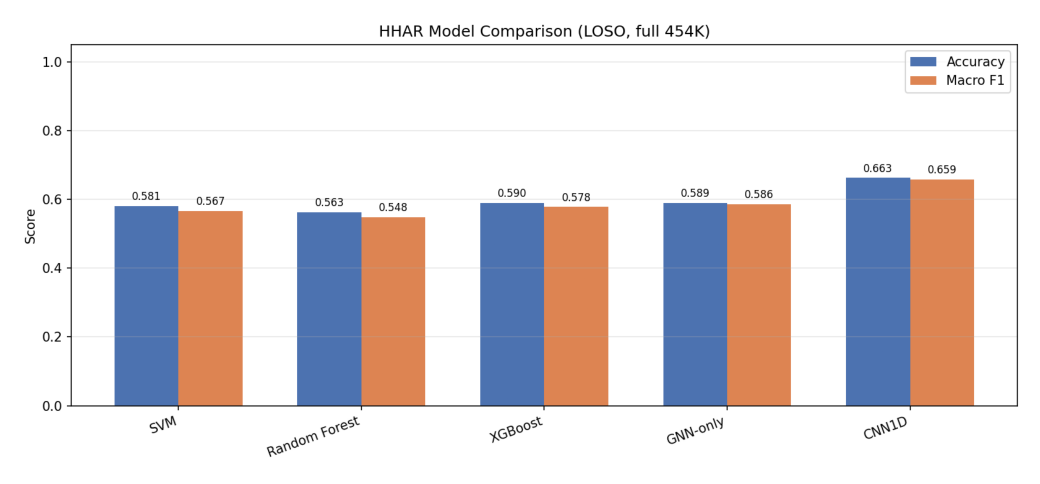

In [4]:
## HHAR Model Comparison Chart
img = mpimg.imread(PLOTS / 'hhar_model_comparison.png')
fig, ax = plt.subplots(figsize=(11, 5))
ax.imshow(img); ax.axis('off')
plt.tight_layout(); plt.show()


## 4. Results Comparison

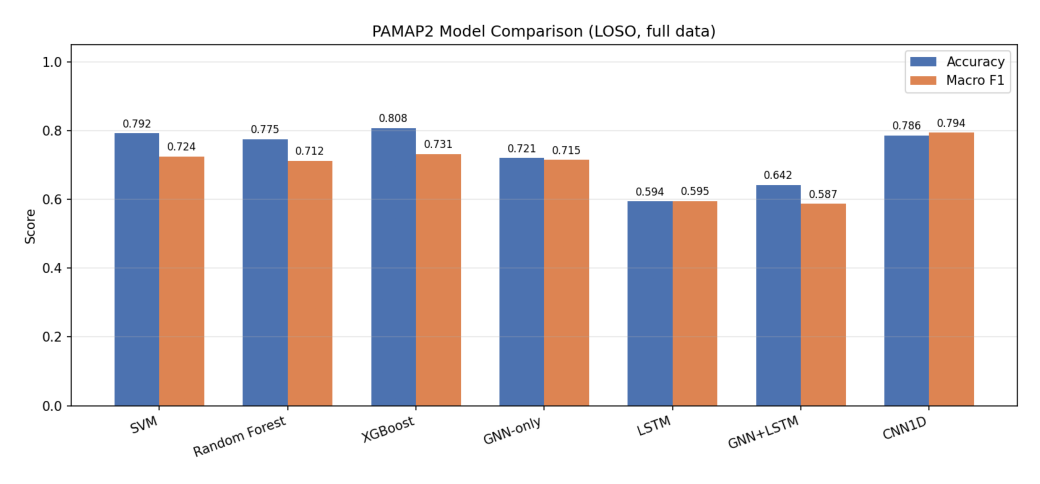

In [5]:
## PAMAP2 Model Comparison Chart
img = mpimg.imread(PLOTS / 'pamap2_model_comparison.png')
fig, ax = plt.subplots(figsize=(11, 5))
ax.imshow(img); ax.axis('off')
plt.tight_layout(); plt.show()


## 5. SHAP Feature Importance (Random Forest)

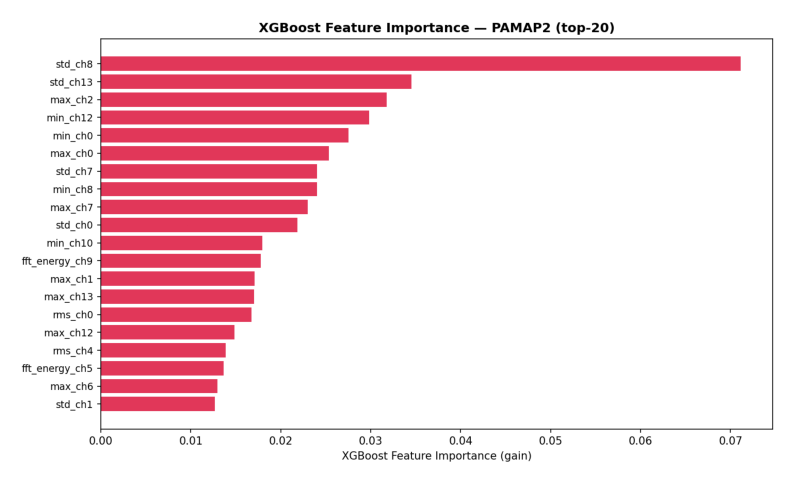


Top 10 XGBoost features (PAMAP2):
  std_ch8                        0.0711
  std_ch13                       0.0345
  max_ch2                        0.0318
  min_ch12                       0.0298
  min_ch0                        0.0275
  max_ch0                        0.0253
  std_ch7                        0.0240
  min_ch8                        0.0240
  max_ch7                        0.0230
  std_ch0                        0.0218


In [6]:
## XGBoost Feature Importance (PAMAP2)
xgb_path = PLOTS / 'xgb_feature_importance_pamap2.png'
if xgb_path.exists():
    img = mpimg.imread(xgb_path)
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.imshow(img); ax.axis('off')
    plt.tight_layout(); plt.show()

# Also print top features from JSON
fi_path = METS / 'xgb_feature_importance.json'
if fi_path.exists():
    fi = json.load(open(fi_path))
    features = fi.get('top_features', [])
    scores   = fi.get('top_importances', [])
    print("\nTop 10 XGBoost features (PAMAP2):")
    for name, score in zip(features[:10], scores[:10]):
        print(f"  {name:<30} {score:.4f}")
